# 00fi · Integration with scVI (**Cross-organ ILCs** visualisation manifold, acrosslifespan/noEMC)

This script generates the integrated .h5ad object necessary for generating the following figures: **Figures 3c; Extended Data Figures 5a-b.**

**Pipeline:**
1. Extract target barcodes from annotation `.csv`
2. For each h5ad: load → subset to target barcodes → save to a dedicated temp folder
3. Concatenate subsetted files on-disk: `join='outer'` (union of genes) and `join='inner'` (shared genes)
4. Inner concat → HVGs (`seurat_v3`) → scVI (`Dataset` batch, `Donor_id` covariate)
5. Transfer `X_scVI` to outer concat → KNN → UMAP → Leiden
6. Map celltype annotations onto integrated object and save

## Configuration

In [44]:
import os

# ── Paths ─────────────────────────────────────────────────────────────────────
OBJECT     = "crossdisease_ILC_visualisation"
MAIN_DIR   = "/nfs/team292/projects/PanTissue/"
INPUT_DIR  = os.path.join(MAIN_DIR, "results/temp/anndata_copy_freeze/")
H5AD_PATHS_LOAD = {
    "IPF_NatGen2024_vl6": "/nfs/team292/projects/PanTissue/results/temp/02_annotation/immune/acrosslifespan/noHormones/04_crossdisease_ILC/IPF_NatGen2024_ILC_vl6.h5ad",
    "IPF_SciAdv2020_vl6": "/nfs/team292/projects/PanTissue/results/temp/02_annotation/immune/acrosslifespan/noHormones/04_crossdisease_ILC/IPF_SciAdv2020_ILC_vl6.h5ad",
    "Periodontitis_vl6": "/nfs/team292/projects/PanTissue/results/temp/02_annotation/immune/acrosslifespan/noHormones/04_crossdisease_ILC/Periodontitis_ILC_vl6.h5ad",
    "UlcerativeColitis_vl6": "/nfs/team292/projects/PanTissue/results/temp/02_annotation/immune/acrosslifespan/noHormones/04_crossdisease_ILC/UlcerativeColitis_ILC_vl6.h5ad"
}

# Annotation CSV
ANNOTATION_CSV = os.path.join(MAIN_DIR, "results/temp/02_annotation/immune/acrosslifespan/noHormones/04_crossdisease_ILC/20260526_crossdisease_ILC_annotations.csv")
LINEAGE_COL    = "L3"
LINEAGE_TARGET = [
    "ILC3",
    "uNK",
    "pNK",
    "NK_Cyc"
]

# Temporary folder for per-dataset subsetted h5ads (created here, used for concat)
SUBSET_DIR = os.path.join(MAIN_DIR, f"results/temp/00_preprocessing_{OBJECT}/")

# Integration outputs
OUTPUT_DIR        = os.path.join(MAIN_DIR, "results/temp/01_integration/")
CONCAT_H5AD_OUTER = os.path.join(OUTPUT_DIR, f"concat_{OBJECT}_outer.h5ad")
CONCAT_H5AD_INNER = os.path.join(OUTPUT_DIR, f"concat_{OBJECT}_inner.h5ad")
INTEGRATED_H5AD   = os.path.join(OUTPUT_DIR, f"integrated_scvi_{OBJECT}.h5ad")
SCVI_MODEL_DIR    = os.path.join(OUTPUT_DIR, f"scvi_model_{OBJECT}")

os.makedirs(SUBSET_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── HVG parameters ───────────────────────────────────────────────────────────
N_HVG      = 1500   # fewer cells → fewer HVGs to avoid over-fitting
HVG_FLAVOR = "seurat_v3"
HVGs_BATCH_COL   = None  # column used as batch key for HVGs calculation

# ── scVI batch Column names in obs ───────────────────────────────────────────────────────
DATASET_COL      = "Dataset"   # batch key for scVI
DONOR_COL        = "Donor_id"  # covariate key for scVI
CELL_CYCLE_PHASE = "phase"     # covariate key for scVI

# ── scVI parameters ───────────────────────────────────────────────────────────
N_LATENT        = 60
N_LAYERS        = 1
GENE_LIKELIHOOD = "nb"
MAX_EPOCHS      = 200
EARLY_STOPPING  = True
DISPERSION      = 'gene-batch' #gene-batch

# ── Neighbours / UMAP parameters ─────────────────────────────────────────────
N_NEIGHBORS       = 30
LEIDEN_RESOLUTION = 1

# ── Misc ─────────────────────────────────────────────────────────────────────
RANDOM_SEED = 42
N_CPUS      = 8

## Libraries

In [45]:
import warnings
warnings.filterwarnings("ignore")

import gc
import glob as glob_mod

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import scvi
from anndata.experimental import concat_on_disk

sc.settings.verbosity = 3
sc.settings.n_jobs    = N_CPUS
sc.set_figure_params(dpi=100, frameon=False, figsize=(6, 5))
ad.settings.allow_write_nullable_strings = True

print(f"anndata  : {ad.__version__}")
print(f"scanpy   : {sc.__version__}")
print(f"scvi     : {scvi.__version__}")

anndata  : 0.12.6
scanpy   : 1.12
scvi     : 1.4.2


## 1 · Load annotation and identify immune barcodes

In [46]:
if not os.path.exists(ANNOTATION_CSV):
    raise FileNotFoundError(
        f"Annotation CSV not found: {ANNOTATION_CSV}\n"
        "Run 03_annotation_postnatal.ipynb first."
    )

ann = pd.read_csv(ANNOTATION_CSV, index_col="barcode")
print(f"Annotation CSV loaded: {len(ann):,} cells total")
print(f"\nLineage distribution:")
print(ann[LINEAGE_COL].value_counts())

Annotation CSV loaded: 59,967 cells total

Lineage distribution:
L3
uNK       27150
pNK       17696
ILC3       3780
NK_Cyc     3089
Name: count, dtype: int64


In [47]:
selected_barcodes = set(ann.index[ann[LINEAGE_COL].isin(LINEAGE_TARGET)])
lineage_str = ", ".join(LINEAGE_TARGET)
print(f"{lineage_str} barcodes identified: {len(selected_barcodes):,}")

ILC3, uNK, pNK, NK_Cyc barcodes identified: 51,715


## 2a · Subset ReproTract h5ads

Each postnatal dataset is loaded individually, subset to immune barcodes, and saved to `SUBSET_DIR`.  
This keeps peak memory proportional to a single dataset rather than the full atlas.

In [48]:
# ── Discover source h5ads ───────────────────────────────────────────────
all_paths = sorted(glob_mod.glob(os.path.join(INPUT_DIR, "*.h5ad")))
source_paths = all_paths

if len(source_paths) == 0:
    raise FileNotFoundError(
        f"No h5ad files found in {INPUT_DIR}\n"
        "Expected filenames containing '.h5ad'."
    )

print(f"Source datasets ({len(source_paths)}):")
for p in source_paths:
    print(f"  {os.path.basename(p)}")

Source datasets (27):
  cervix_adult_Guo2023-denoised.h5ad
  fallopiantube_adult_sanger-denoised.h5ad
  fallopiantube_adult_urlich2022-denoised.h5ad
  fallopiantube_adult_weigert2025-denoised.h5ad
  gonad_fetal_lardenois2026-denoised.h5ad
  gonad_fetal_taelman2024-denoised.h5ad
  ovary_adult_gaylord2025-denoised.h5ad
  ovary_adult_guahmich2023-denoised.h5ad
  ovary_adult_jones2024-denoised.h5ad
  ovary_adult_sanger-denoised.h5ad
  ovary_adult_wagner2020-denoised.h5ad
  ovary_fetal_garciaalonso2022-denoised.h5ad
  ovary_fetal_wamaitah-denoised.h5ad
  ovary_paediatric_sanger-denoised.h5ad
  reptract_fetal_lorenzi2025-denoised.h5ad
  uterus_adult_Huang2023-denoised.h5ad
  uterus_adult_Liu2025-denoised.h5ad
  uterus_adult_Wang2020-denoised.h5ad
  uterus_adult_burns2026-denoised.h5ad
  uterus_adult_garciaalonso2021-denoised.h5ad
  uterus_adult_mareckova2024-denoised.h5ad
  uterus_adult_menstrualfluid_sanger-denoised.h5ad
  uterus_adult_sanger-denoised.h5ad
  uterus_adult_tan2022-denoised.h5

In [49]:
skipped = []

for src_path in source_paths:
    name     = os.path.splitext(os.path.basename(src_path))[0]
    out_path = os.path.join(SUBSET_DIR, f"{name}.h5ad")

    if os.path.exists(out_path):
        print(f"  {name}: subset already exists — skipping.")
        continue

    print(f"  {name}: loading …", end=" ", flush=True)
    adata = ad.read_h5ad(src_path)
    
    # Select barcodes in selected_barcodes
    combined_mask = adata.obs_names.isin(selected_barcodes)
    
    n_keep = int(combined_mask.sum())
    print(f"{adata.n_obs:,} cells → {n_keep:,} kept", end=" ", flush=True)

    if n_keep < 5:
        print(f"— < 5 cells after filtering, skipping.")
        skipped.append(name)
        del adata
        gc.collect()
        continue

    # Subset and save
    adata_subset = adata[combined_mask].copy()
    del adata
    gc.collect()

    adata_subset.write_h5ad(out_path)
    print(f"→ saved.")
    del adata_subset
    gc.collect()

print(f"\nDone. Skipped datasets: {skipped if skipped else 'none'}")

  cervix_adult_Guo2023-denoised: loading … 15,403 cells → 639 kept → saved.
  fallopiantube_adult_sanger-denoised: loading … 54,078 cells → 1,157 kept → saved.
  fallopiantube_adult_urlich2022-denoised: loading … 64,195 cells → 730 kept → saved.
  fallopiantube_adult_weigert2025-denoised: loading … 180,440 cells → 1,321 kept → saved.
  gonad_fetal_lardenois2026-denoised: loading … 73,420 cells → 39 kept → saved.
  gonad_fetal_taelman2024-denoised: loading … 2,083 cells → 6 kept → saved.
  ovary_adult_gaylord2025-denoised: loading … 57,923 cells → 3 kept — < 5 cells after filtering, skipping.
  ovary_adult_guahmich2023-denoised: loading … 45,561 cells → 0 kept — < 5 cells after filtering, skipping.
  ovary_adult_jones2024-denoised: loading … 27,596 cells → 97 kept → saved.
  ovary_adult_sanger-denoised: loading … 141,904 cells → 101 kept → saved.
  ovary_adult_wagner2020-denoised: loading … 32,763 cells → 4 kept — < 5 cells after filtering, skipping.
  ovary_fetal_garciaalonso2022-denoi

## 2b · Subset CrossDisease h5ads

Each dataset is loaded individually, subset to barcodes, and saved to `SUBSET_DIR`.  
This keeps peak memory proportional to a single dataset rather than the full atlas.

In [50]:
skipped = []

for _,src_path in H5AD_PATHS_LOAD.items():
    # print(src_path)
    name     = os.path.splitext(os.path.basename(src_path))[0]
    out_path = os.path.join(SUBSET_DIR, f"{name}.h5ad")

    if os.path.exists(out_path):
        print(f"  {name}: subset already exists — skipping.")
        continue

    print(f"  {name}: loading …", end=" ", flush=True)
    adata = ad.read_h5ad(src_path)
    
    # Select barcodes in selected_barcodes
    combined_mask = adata.obs_names.isin(selected_barcodes)
    
    n_keep = int(combined_mask.sum())
    print(f"{adata.n_obs:,} cells → {n_keep:,} kept", end=" ", flush=True)

    if n_keep < 5:
        print(f"— < 5 cells after filtering, skipping.")
        skipped.append(name)
        del adata
        gc.collect()
        continue

    # Subset and save
    adata_subset = adata[combined_mask].copy()
    del adata
    gc.collect()

    adata_subset.write_h5ad(out_path)
    print(f"→ saved.")
    del adata_subset
    gc.collect()

print(f"\nDone. Skipped datasets: {skipped if skipped else 'none'}")

  IPF_NatGen2024_ILC_vl6: loading … 11,126 cells → 9,589 kept → saved.
  IPF_SciAdv2020_ILC_vl6: loading … 7,456 cells → 3,226 kept → saved.
  Periodontitis_ILC_vl6: loading … 2,303 cells → 1,783 kept → saved.
  UlcerativeColitis_ILC_vl6: loading … 610 cells → 594 kept → saved.

Done. Skipped datasets: none


## 3 · Concatenate subsetted files on disk

In [51]:
# ── Collect the subsetted h5ads ───────────────────────────────────────────────
subset_paths = sorted(glob_mod.glob(os.path.join(SUBSET_DIR, "*.h5ad")))

if len(subset_paths) == 0:
    raise FileNotFoundError(f"No subsetted h5ad files found in {SUBSET_DIR}")

in_files = {
    os.path.splitext(os.path.basename(p))[0]: p
    for p in subset_paths
}

print(f"Datasets to concatenate ({len(in_files)}):")
for k, v in in_files.items():
    print(f"  {k:50s}  {v}")

Datasets to concatenate (28):
  IPF_NatGen2024_ILC_vl6                              /nfs/team292/projects/PanTissue/results/temp/00_preprocessing_crossdisease_ILC_visualisation/IPF_NatGen2024_ILC_vl6.h5ad
  IPF_SciAdv2020_ILC_vl6                              /nfs/team292/projects/PanTissue/results/temp/00_preprocessing_crossdisease_ILC_visualisation/IPF_SciAdv2020_ILC_vl6.h5ad
  Periodontitis_ILC_vl6                               /nfs/team292/projects/PanTissue/results/temp/00_preprocessing_crossdisease_ILC_visualisation/Periodontitis_ILC_vl6.h5ad
  UlcerativeColitis_ILC_vl6                           /nfs/team292/projects/PanTissue/results/temp/00_preprocessing_crossdisease_ILC_visualisation/UlcerativeColitis_ILC_vl6.h5ad
  cervix_adult_Guo2023-denoised                       /nfs/team292/projects/PanTissue/results/temp/00_preprocessing_crossdisease_ILC_visualisation/cervix_adult_Guo2023-denoised.h5ad
  fallopiantube_adult_sanger-denoised                 /nfs/team292/projects/PanTissue/

In [52]:
# ── Outer concat (union of genes) ────────────────────────────────────────────
if os.path.exists(CONCAT_H5AD_OUTER):
    print(f"Outer concat already exists: {CONCAT_H5AD_OUTER}\nSkipping.")
else:
    print("Concatenating (outer — union of genes) …")
    concat_on_disk(
        in_files = in_files,
        out_file = CONCAT_H5AD_OUTER,
        join     = "outer",
        label    = DATASET_COL,
    )
    print(f"Saved → {CONCAT_H5AD_OUTER}")

# ── Inner concat (intersection of genes) ─────────────────────────────────────
if os.path.exists(CONCAT_H5AD_INNER):
    print(f"Inner concat already exists: {CONCAT_H5AD_INNER}\nSkipping.")
else:
    print("Concatenating (inner — intersection of genes) …")
    concat_on_disk(
        in_files = in_files,
        out_file = CONCAT_H5AD_INNER,
        join     = "inner",
        label    = DATASET_COL,
    )
    print(f"Saved → {CONCAT_H5AD_INNER}")

Concatenating (outer — union of genes) …
Saved → /nfs/team292/projects/PanTissue/results/temp/01_integration/concat_crossdisease_ILC_visualisation_outer.h5ad
Concatenating (inner — intersection of genes) …
Saved → /nfs/team292/projects/PanTissue/results/temp/01_integration/concat_crossdisease_ILC_visualisation_inner.h5ad


In [53]:
print("Loading inner concat (intersection of genes) …")
adata_inner = ad.read_h5ad(CONCAT_H5AD_INNER)

# ── Guard against duplicate barcodes ─────────────────────────────────────────
dup_mask = adata_inner.obs_names.duplicated()
if dup_mask.any():
    n_dup = int(dup_mask.sum())
    print(f"WARNING: {n_dup} duplicate barcodes — deduplicating (keeping first).")
    adata_inner = adata_inner[~dup_mask].copy()

# ── Fix sparse matrix dtype mismatch (concat_on_disk can mix int32/int64) ────
if sp.issparse(adata_inner.X) and adata_inner.X.indptr.dtype != adata_inner.X.indices.dtype:
    target_dtype = np.result_type(adata_inner.X.indptr.dtype, adata_inner.X.indices.dtype)
    print(f"Fixing sparse dtype mismatch: indptr={adata_inner.X.indptr.dtype}, "
          f"indices={adata_inner.X.indices.dtype} → {target_dtype}")
    adata_inner.X.indptr  = adata_inner.X.indptr.astype(target_dtype)
    adata_inner.X.indices = adata_inner.X.indices.astype(target_dtype)

print(f"inner : {adata_inner.n_obs:,} cells × {adata_inner.n_vars:,} genes")
print("\nobs columns:", adata_inner.obs.columns.tolist())

Loading inner concat (intersection of genes) …
inner : 51,708 cells × 14,527 genes

obs columns: ['n_genes', 'percent_mito', 'doublet_scores', 'Donor_id', 'Dataset', 'S_score', 'G2M_score', 'phase']


In [54]:
adata_inner.obs[DATASET_COL].value_counts()

Dataset
IPF_NatGen2024_ILC_vl6                         9589
uterus_adult_Huang2023-denoised                7703
uterus_adult_urlich2024-denoised               4244
uterus_adult_Liu2025-denoised                  3657
uterus_adult_sanger-denoised                   3337
uterus_adult_burns2026-denoised                3271
IPF_SciAdv2020_ILC_vl6                         3226
uterus_adult_menstrualfluid_sanger-denoised    2692
uterus_adult_garciaalonso2021-denoised         2577
Periodontitis_ILC_vl6                          1783
uterus_adult_Wang2020-denoised                 1383
fallopiantube_adult_weigert2025-denoised       1321
uterus_adult_tan2022-denoised                  1162
fallopiantube_adult_sanger-denoised            1157
fallopiantube_adult_urlich2022-denoised         730
uterus_menopause_sanger-denoised                709
cervix_adult_Guo2023-denoised                   639
UlcerativeColitis_ILC_vl6                       594
ovary_fetal_garciaalonso2022-denoised           566
uter

In [55]:
donors = adata_inner.obs[DONOR_COL].unique()
print(', '.join(donors))

VUILD93, VUILD95, VUILD96, VUILD97, TILD084, THD0015, VUHD103, VUHD104, VUHD106, VUHD107, VUILD82, VUILD83, VUILD84, VUILD88, VUILD90, VUILD91, THD0019, TILD103, TILD116, VUILD100, THD0021, THD0022, THD0023, TILD123, TILD136, VUHD108, VUHD109, VUHD111, VUHD112, VUHD113, VUHD115, VUHD117, VUILD102, VUILD104, VUILD108, TILD109, TILD113, VUILD89, VUILD85, VUILD86, VUILD87, VUILD98, VUILD99, THD0007, THD0008, TILD049, TILD051, TILD055, TILD062, VUHD84, VUHD85, VUILD79, VUILD73, VUILD77, TILD039, TILD041, VUILD67, VUILD68, VUILD48, VUILD53, VUILD55, VUHD65, VUHD66, VUILD57, VUILD58, VUHD67, VUHD68, VUILD59-2, VUILD59-1, VUHD69, VUILD60-2, VUILD60-1, THD0001, VUILD61-2, VUILD61-1, VUHD70, VUILD62-1, VUILD62-2, TILD015, VUILD63, VUILD64, VUILD65, VUHD71, THD0002, THD0005, TILD006, TILD028, TILD019, BM150, BM156, BM157, BM158, GM136, GM143, GM144, GM147, GM148, GM183, GM184a, GM238, GM241, GM242, PD134, PD153, PD161b, PD164, BM165, BM168, BM169, GM169, GM283, GM289, PD164b, PD164c, PD170, 198,

## 4 · Highly variable genes stratified by menstrual stage

In [56]:
sc.pp.filter_genes(adata_inner, min_cells=5)

filtered out 35 genes that are detected in less than 5 cells


Identifying 1500 HVGs on inner concat (14,492 shared genes) …
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
HVGs selected: 1500


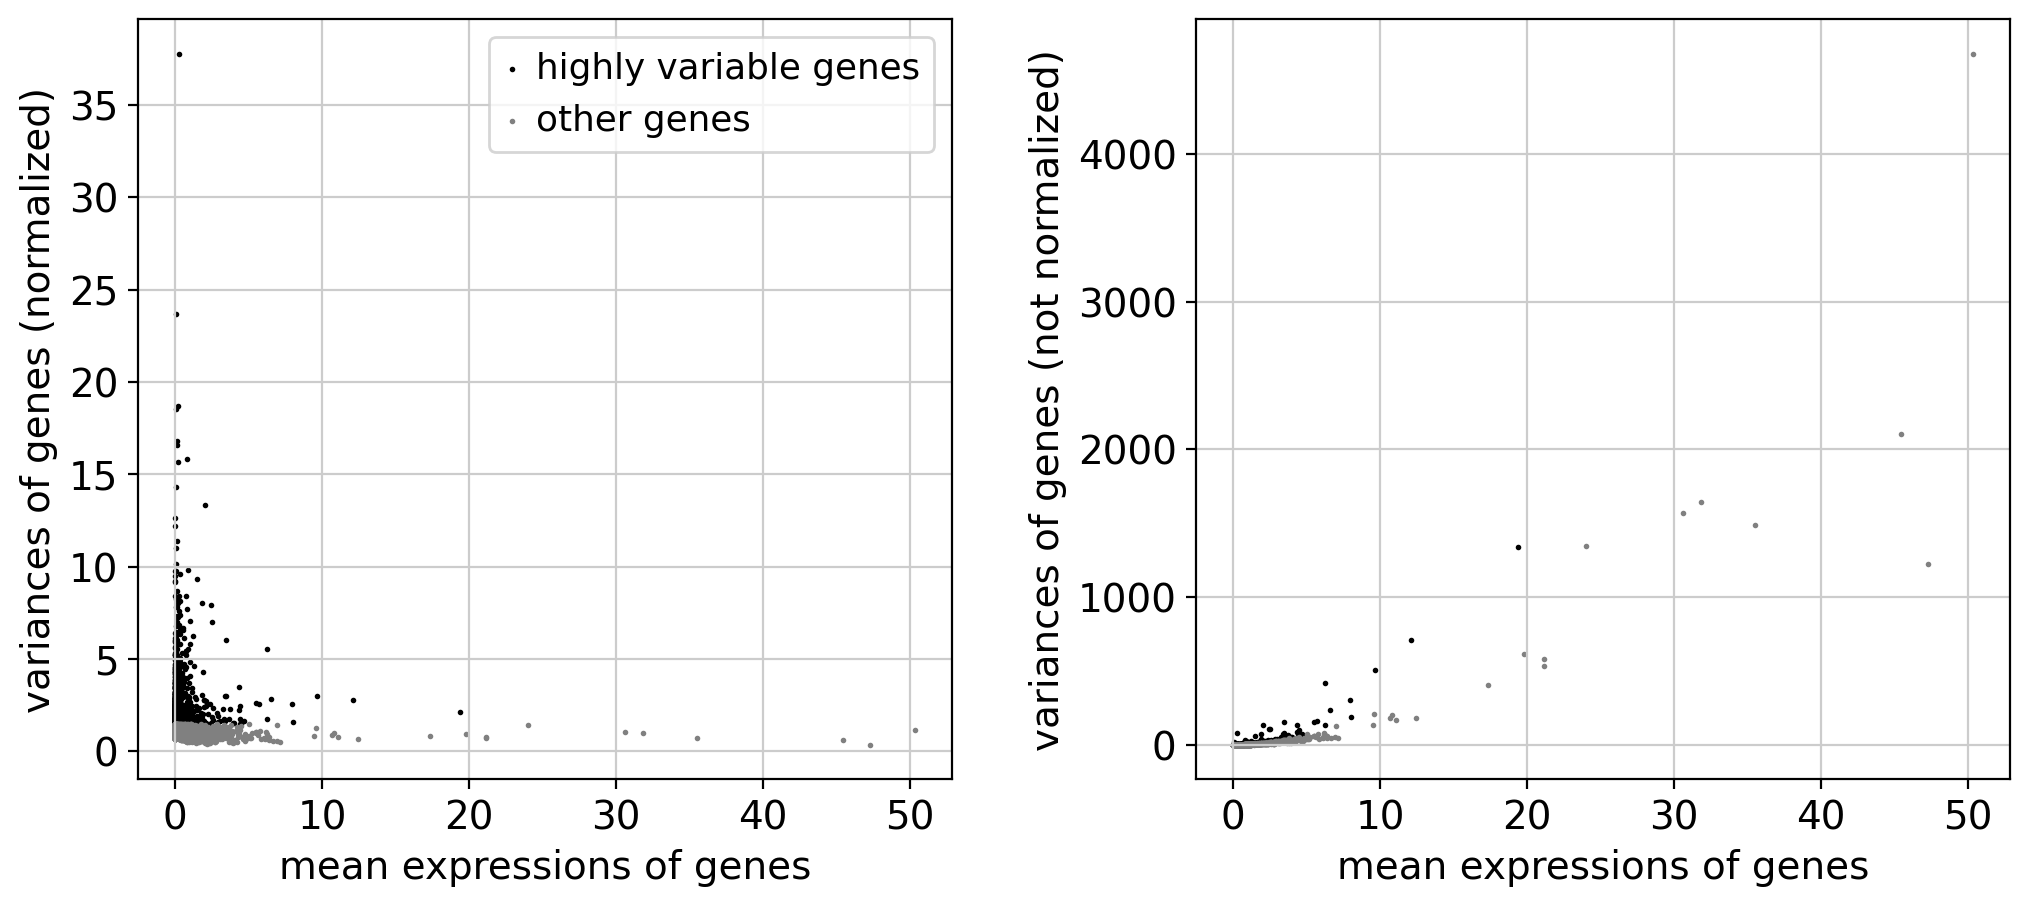

In [57]:
print(f"Identifying {N_HVG} HVGs on inner concat "
      f"({adata_inner.n_vars:,} shared genes) …")

# Check if a batch column is provided and exists in obs
use_batch = (HVGs_BATCH_COL is not None) and (HVGs_BATCH_COL in adata_inner.obs)

if use_batch and adata_inner.obs[HVGs_BATCH_COL].nunique() > 1:
    print(f"Running HVG with batch key: {HVGs_BATCH_COL}")
    sc.pp.highly_variable_genes(
        adata_inner,
        n_top_genes = N_HVG,
        flavor      = HVG_FLAVOR,
        batch_key   = HVGs_BATCH_COL,
        subset      = False,
    )
else:
    # Logic for when HVGs_BATCH_COL is None OR there is only 1 unique batch
    reason = "no batch column provided" if not use_batch else "only one unique batch found"
    print(f"WARNING: Running HVG without stratification ({reason}).")
    
    sc.pp.highly_variable_genes(
        adata_inner,
        n_top_genes = N_HVG,
        flavor      = HVG_FLAVOR,
        subset      = False,
    )

inner_genes_set = set(adata_inner.var_names)
hvg_set         = set(adata_inner.var_names[adata_inner.var.highly_variable])
print(f"HVGs selected: {len(hvg_set)}")
sc.pl.highly_variable_genes(adata_inner)

In [58]:
adata_hvg = adata_inner[:, adata_inner.var.highly_variable].copy()
del adata_inner
gc.collect()
print(f"adata_hvg (HVGs only): {adata_hvg}")

adata_hvg (HVGs only): AnnData object with n_obs × n_vars = 51708 × 1500
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'Donor_id', 'Dataset', 'S_score', 'G2M_score', 'phase'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'


## 5 · Batch correction with scVI

In [59]:
adata_hvg.obs[DONOR_COL] = adata_hvg.obs[DONOR_COL].astype(str)

In [60]:
scvi.settings.seed = RANDOM_SEED

if DONOR_COL not in adata_hvg.obs.columns:
    raise ValueError(f"Column '{DONOR_COL}' not found. Available: {adata_hvg.obs.columns.tolist()}")

print(f"Number of donors: {adata_hvg.obs[DONOR_COL].nunique()}")
print(f"Number of datasets: {adata_hvg.obs[DATASET_COL].nunique()}")

scvi.model.SCVI.setup_anndata(
    adata_hvg,
    batch_key                  = DATASET_COL,
    categorical_covariate_keys = [DONOR_COL, CELL_CYCLE_PHASE],
)

model = scvi.model.SCVI(
    adata_hvg,
    n_latent        = N_LATENT,
    n_layers        = N_LAYERS,
    gene_likelihood = GENE_LIKELIHOOD,
    dispersion      = DISPERSION
)
model

Seed set to 42


Number of donors: 347
Number of datasets: 28


SCVI model with the following parameters: 
n_hidden: 128, n_latent: 60, n_layers: 1, dropout_rate: 0.1, dispersion: gene-batch, gene_likelihood: nb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [61]:
model.train(
    max_epochs     = MAX_EPOCHS,
    early_stopping = EARLY_STOPPING,
)
model.save(SCVI_MODEL_DIR, overwrite=True)
print(f"Model saved → {SCVI_MODEL_DIR}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-GPU-c92e82f0-acdb-bfba-5c7c-90306242f281/11/0]


Epoch 200/200: 100%|██████████| 200/200 [08:43<00:00,  2.63s/it, v_num=1, train_loss=459]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|██████████| 200/200 [08:43<00:00,  2.62s/it, v_num=1, train_loss=459]
Model saved → /nfs/team292/projects/PanTissue/results/temp/01_integration/scvi_model_crossdisease_ILC_visualisation


Loading outer concat (union of genes) …
outer : 51,708 cells × 35,943 genes
X_scVI transferred: shape (51708, 60)
in_inner: 14,492 genes  |  in_hvg: 1,500 genes


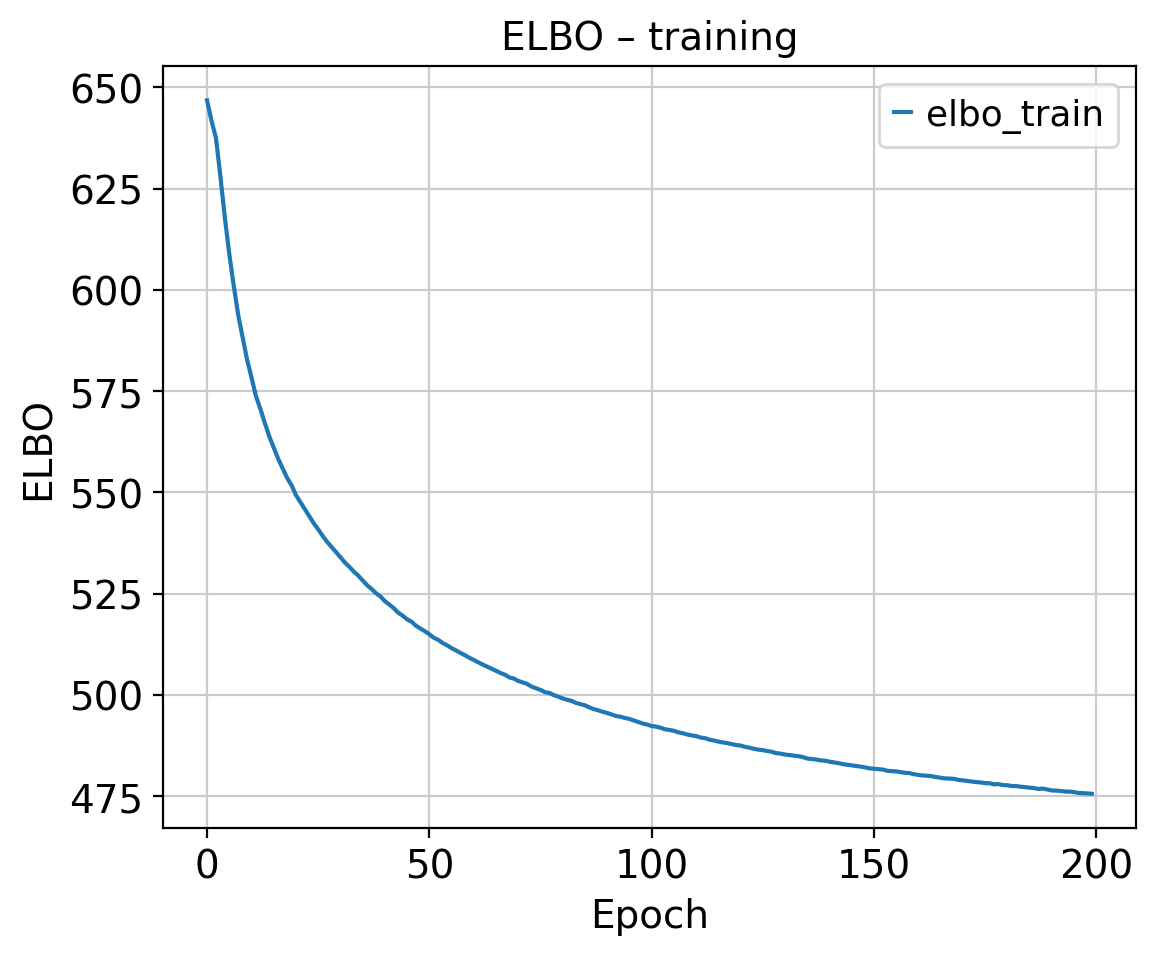

In [62]:
X_scVI = model.get_latent_representation()

del adata_hvg
gc.collect()

print("Loading outer concat (union of genes) …")
adata = ad.read_h5ad(CONCAT_H5AD_OUTER)

# ── Guard against duplicate barcodes ─────────────────────────────────────────
dup_mask = adata.obs_names.duplicated()
if dup_mask.any():
    n_dup = int(dup_mask.sum())
    print(f"WARNING: {n_dup} duplicate barcodes — deduplicating (keeping first).")
    adata = adata[~dup_mask].copy()

# ── Fix sparse matrix dtype mismatch ─────────────────────────────────────────
if sp.issparse(adata.X) and adata.X.indptr.dtype != adata.X.indices.dtype:
    target_dtype = np.result_type(adata.X.indptr.dtype, adata.X.indices.dtype)
    print(f"Fixing sparse dtype mismatch: indptr={adata.X.indptr.dtype}, "
          f"indices={adata.X.indices.dtype} → {target_dtype}")
    adata.X.indptr  = adata.X.indptr.astype(target_dtype)
    adata.X.indices = adata.X.indices.astype(target_dtype)

print(f"outer : {adata.n_obs:,} cells × {adata.n_vars:,} genes")

adata.obsm["X_scVI"]         = X_scVI
adata.var["in_inner"]        = adata.var_names.isin(inner_genes_set)
adata.var["in_hvg"]          = adata.var_names.isin(hvg_set)
adata.var["highly_variable"] = adata.var["in_hvg"]

del X_scVI
print(f"X_scVI transferred: shape {adata.obsm['X_scVI'].shape}")
print(f"in_inner: {adata.var['in_inner'].sum():,} genes  |  in_hvg: {adata.var['in_hvg'].sum():,} genes")

model.history["elbo_train"].plot()
plt.title("ELBO – training")
plt.ylabel("ELBO")
plt.xlabel("Epoch")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"scvi_{OBJECT}.png"), dpi=150)
plt.show()

## 6 · KNN graph, UMAP and Leiden clustering

In [63]:
import numba

print("Numba threads available:", numba.get_num_threads())
print("Numba config NUM_THREADS:", numba.config.NUMBA_NUM_THREADS)
print("CPUs visible to OS:", os.cpu_count())
print("CPUs in affinity mask:", len(os.sched_getaffinity(0)))
os.sched_setaffinity(0, range(64))
print("CPUs in affinity mask:", len(os.sched_getaffinity(0)))

from pynndescent import PyNNDescentTransformer

transformer = PyNNDescentTransformer(
    n_neighbors=N_NEIGHBORS,
    metric="euclidean",
    n_jobs=None,   # explicitly limit to 1
    random_state=RANDOM_SEED,
)

Numba threads available: 1
Numba config NUM_THREADS: 1
CPUs visible to OS: 64
CPUs in affinity mask: 1
CPUs in affinity mask: 1


In [64]:
_use_rapids = False
try:
    import rapids_singlecell as rsc
    import cupy as cp
    rsc.get.anndata_to_GPU(adata)
    rsc.pp.neighbors(
        adata,
        n_neighbors = N_NEIGHBORS+1,
        use_rep     = "X_scVI",
        algorithm   = "cagra",
        metric      = "euclidean",
    )
    rsc.get.anndata_to_CPU(adata)
    _use_rapids = True
    print("KNN computed with CAGRA (rapids_singlecell, GPU).")
except ImportError:
    print("rapids_singlecell not available — falling back to scanpy (pynndescent).")

if not _use_rapids:
    sc.pp.neighbors(
        adata,
        n_neighbors  = N_NEIGHBORS,
        use_rep      = "X_scVI",
        method       = "umap",
        # metric       = "euclidean",
        # random_state = RANDOM_SEED,
        transformer= transformer, # New, test with more cores to initialize jupyterlab
    )
    print("KNN computed with pynndescent (scanpy, CPU).")

rapids_singlecell not available — falling back to scanpy (pynndescent).
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:09)
KNN computed with pynndescent (scanpy, CPU).


In [65]:
sc.tl.umap(adata, random_state=RANDOM_SEED)
print("UMAP coordinates stored in adata.obsm['X_umap'].")

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:28)
UMAP coordinates stored in adata.obsm['X_umap'].


In [66]:
# if _use_rapids:
#     rsc.tl.leiden(
#         adata,
#         resolution   = LEIDEN_RESOLUTION,
#         random_state = RANDOM_SEED,
#         key_added    = "leiden",
#     )
# else:
#     sc.tl.leiden(
#         adata,
#         resolution   = LEIDEN_RESOLUTION,
#         random_state = RANDOM_SEED,
#         key_added    = "leiden",
#         flavor       = "igraph",
#         n_iterations = 2,
#         directed     = False,
#     )
# print(f"Leiden clusters (res={LEIDEN_RESOLUTION}): {adata.obs['leiden'].nunique()} clusters")
# print(adata.obs["leiden"].value_counts().sort_index())

## 7 · Save integrated object

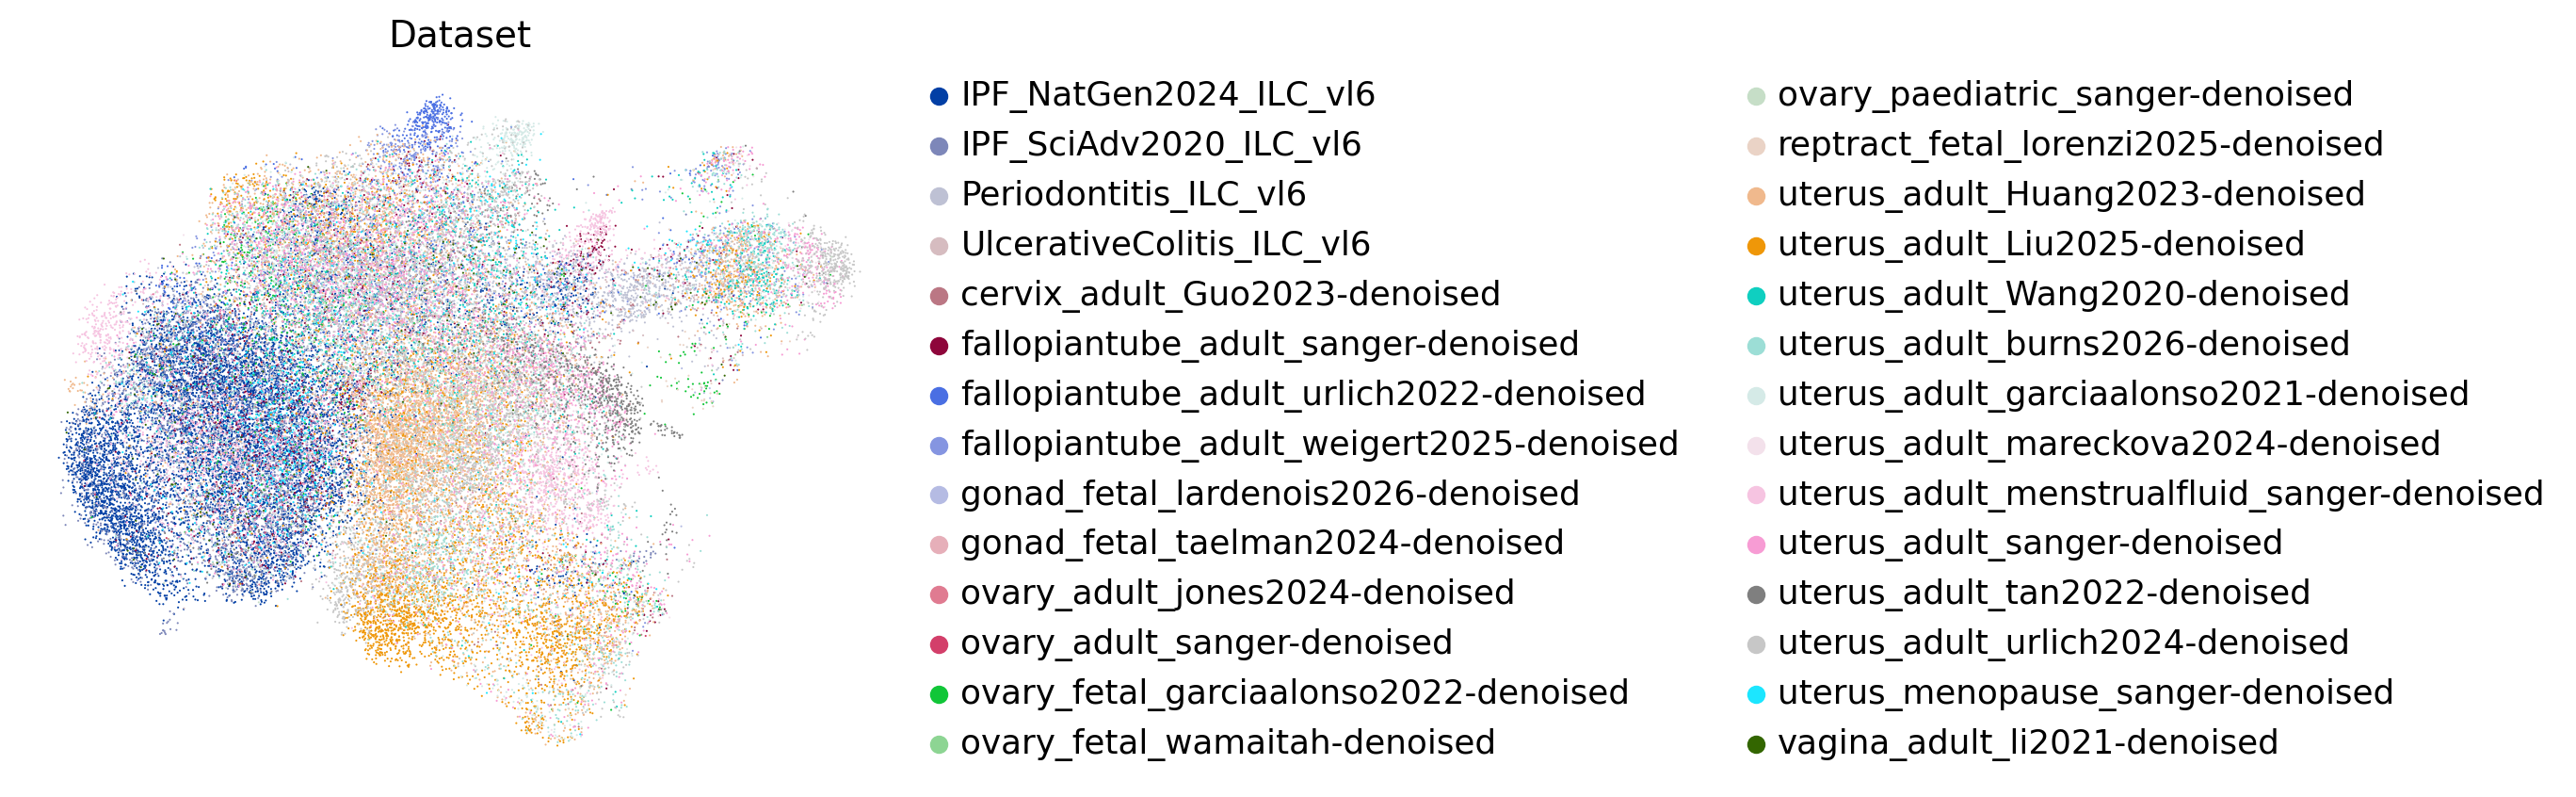

In [67]:
sc.pl.umap(adata, color = DATASET_COL)

In [68]:
# ── Prior annotation (optional) ───────────────────────────────────────────────
# Maps a column from a prior annotation CSV into adata.obs (no subsetting).
# The CSV must have a 'barcode' index column. Set to None to skip.
PRIOR_ANN_CSV = ANNOTATION_CSV
PRIOR_ANN_COL = "celltype"
PRIOR_BAR_COL = "barcode"

# ── Map prior annotation to obs ───────────────────────────────────────────────
# Reads PRIOR_ANN_CSV and maps PRIOR_ANN_COL into adata.obs by barcode.
# Cells not present in the CSV receive NaN. No subsetting is performed.

if PRIOR_ANN_CSV and os.path.exists(PRIOR_ANN_CSV):
    prior = pd.read_csv(PRIOR_ANN_CSV, index_col=PRIOR_BAR_COL)
    # prior.index = prior.index.astype(str) + "-1"
    if PRIOR_ANN_COL in prior.columns:
        adata.obs[PRIOR_ANN_COL] = adata.obs_names.map(prior[PRIOR_ANN_COL])
        n_mapped = adata.obs[PRIOR_ANN_COL].notna().sum()
        print(f"Mapped '{PRIOR_ANN_COL}' from {PRIOR_ANN_CSV}")
        print(f"  {n_mapped:,} / {adata.n_obs:,} cells annotated")
        print(adata.obs[PRIOR_ANN_COL].value_counts(dropna=False))
    else:
        print(f"WARNING: column '{PRIOR_ANN_COL}' not found in {PRIOR_ANN_CSV}")
        print(f"  Available columns: {prior.columns.tolist()}")
elif PRIOR_ANN_CSV:
    print(f"WARNING: prior annotation CSV not found:\n  {PRIOR_ANN_CSV}")
else:
    print("No prior annotation CSV specified (PRIOR_ANN_CSV = None) — skipping.")

# Rename
adata.obs = adata.obs.rename(columns={PRIOR_ANN_COL: 'celltype'})

Mapped 'celltype' from /nfs/team292/projects/PanTissue/results/temp/02_annotation/immune/acrosslifespan/noHormones/04_crossdisease_ILC/20260526_crossdisease_ILC_annotations.csv
  51,708 / 51,708 cells annotated
celltype
NK_CD16hi                      16117
uNK3                           12192
uNK2                            9708
uNK1                            5249
ILC3_NCRhi                      3425
NK_Cyc                          3089
NK_CD56dim_CD16dim_SPTSSBhi     1573
ILC3_NCRlo/LTi                   355
Name: count, dtype: int64


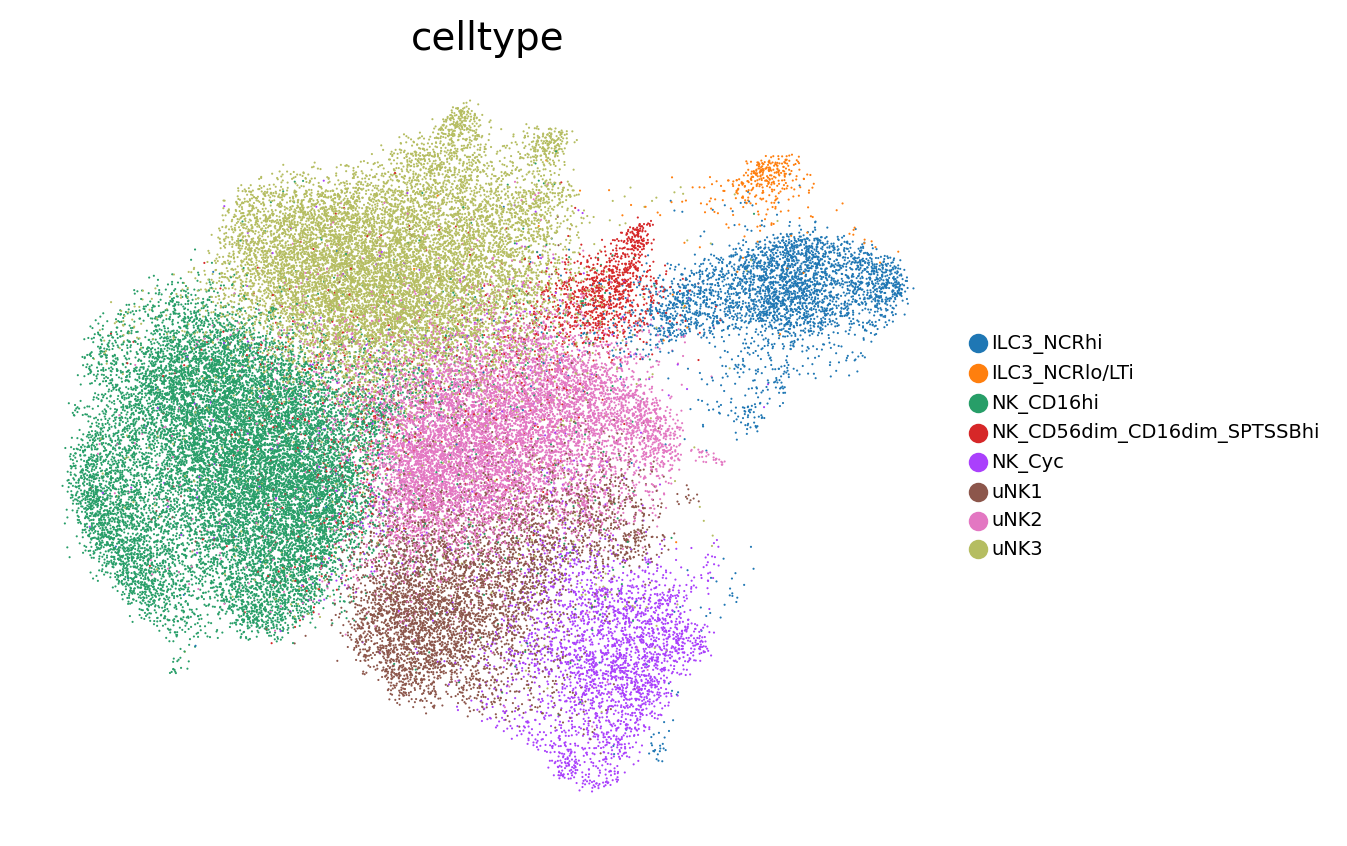

In [69]:
# 3. Cast to category for plotting
sc.pl.umap(
    adata,
    color           = "celltype",
    # legend_loc      = "on data",
    legend_fontsize = 7,
)

In [70]:
adata.write_h5ad(INTEGRATED_H5AD)
print(f"Integrated object saved → {INTEGRATED_H5AD}")
print(adata)

Integrated object saved → /nfs/team292/projects/PanTissue/results/temp/01_integration/integrated_scvi_crossdisease_ILC_visualisation.h5ad
AnnData object with n_obs × n_vars = 51708 × 35943
    obs: 'n_counts', 'n_genes', 'sample_id', 'percent_mito', 'percent_ribo', 'doublet_scores', 'project', 'Donor_id', 'Tissue', 'age', 'gender', 'Patient_status', 'Dataset', 'batch', 'info', 'Diagnosis', 'smoking_status', 'S_score', 'G2M_score', 'phase', 'leiden', 'leiden_R', 'leiden_2', 'immune_annotations', 'orig_barcode', 'Organism', 'Source_Name', 'Status', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Sample_id', 'Library_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Disso